# Task 2 — Unsupervised Domain Adaptation on PACS

This notebook is the single entry point for the Task 2 experiment. It trains Source-only ERM, DAN, DANN, and CDAN with one shared protocol, selects checkpoints using **only** mean macro-F1 over the three source validation domains, and reveals Sketch labels only in the final analysis sections.

Run the notebook from top to bottom. Generated files are written below `task2/results/`. Large checkpoints and caches are intentionally ignored by Git.


## 1. Setup and global configuration

The experiment uses seed 6304 throughout. CUDA runs prefer bfloat16 autocast when the GPU supports it (its wider exponent range prevents adversarial-training activation overflow), otherwise they use fp16 with gradient scaling; CPU fallback uses bfloat16. Every ResNet input is channels-last, cuDNN benchmarking is enabled for the fixed 224×224 input, and every DataLoader is constructed by the guarded helper below with `num_workers=0`.


In [1]:
from __future__ import annotations

import hashlib
import itertools
import json
import math
import os
import random
from contextlib import nullcontext
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, Iterator, Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset, Subset
from tqdm.auto import tqdm
from torchvision import datasets, transforms
from torchvision.models import ResNet18_Weights, resnet18

SEED = 6304
SOURCE_DOMAINS = ("photo", "art_painting", "cartoon")
TARGET_DOMAIN = "sketch"
NUM_CLASSES = 7
SOURCE_BATCH_PER_DOMAIN = 8
TARGET_BATCH_SIZE = 24
EVAL_BATCH_SIZE = 128
MAX_EPOCHS = 30
PATIENCE = 5
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

TASK_DIR = Path.cwd().resolve()
if TASK_DIR.name != "task2":
    candidate = TASK_DIR / "task2"
    if candidate.is_dir():
        TASK_DIR = candidate
RESULTS_DIR = TASK_DIR / "results"
CHECKPOINT_DIR = RESULTS_DIR / "checkpoints"
CURVE_DIR = RESULTS_DIR / "training_curves"
CONFUSION_DIR = RESULTS_DIR / "confusion_matrices"
CACHE_DIR = RESULTS_DIR / "cache"
for directory in (RESULTS_DIR, CHECKPOINT_DIR, CURVE_DIR, CONFUSION_DIR, CACHE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CUDA_BF16_SUPPORTED = (
    DEVICE.type == "cuda" and torch.cuda.is_bf16_supported()
)
AMP_DTYPE = (
    torch.bfloat16 if DEVICE.type == "cpu" or CUDA_BF16_SUPPORTED else torch.float16
)
torch.backends.cudnn.benchmark = True

def seed_everything(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

seed_everything()
print(f"Device: {DEVICE}; autocast dtype: {AMP_DTYPE}; seed: {SEED}")


Device: cuda; autocast dtype: torch.bfloat16; seed: 6304


In [2]:
def amp_context():
    """Autocast context used around every neural-network forward pass."""
    return torch.autocast(device_type=DEVICE.type, dtype=AMP_DTYPE, enabled=True)

def make_grad_scaler():
    # Current unified AMP API; scaling is needed for fp16, not bfloat16.
    return torch.amp.GradScaler(
        "cuda",
        enabled=(DEVICE.type == "cuda" and AMP_DTYPE == torch.float16)
    )

def make_loader(dataset, *, batch_size, shuffle=False, drop_last=False, generator=None):
    """The only DataLoader constructor used in this notebook."""
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=0,
        pin_memory=(DEVICE.type == "cuda"),
        generator=generator,
    )

def freeze_batchnorm_running_stats(model: nn.Module) -> None:
    """Freeze BN running statistics while leaving affine gamma/beta trainable."""
    for module in model.modules():
        if isinstance(module, nn.modules.batchnorm._BatchNorm):
            module.eval()

def train_mode_with_frozen_bn(*modules: Optional[nn.Module]) -> None:
    for module in modules:
        if module is not None:
            module.train()
            freeze_batchnorm_running_stats(module)

def emit_figure(fig, description: str, path: Path) -> None:
    """Save/show a figure without rendering its title into the image."""
    fig.tight_layout()
    print(f"Figure: {description}")
    fig.savefig(path, dpi=180, bbox_inches="tight")
    print(f"Figure: {description}")
    plt.show()
    plt.close(fig)

def json_dump(payload, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as handle:
        json.dump(payload, handle, indent=2)


## 2. PACS loading and the shared source split

Set `PACS_ROOT` to either the PACS directory itself or its parent. Common layouts such as `PACS/kfold/photo/...` and domain names containing spaces or capitals are recognized. The complete Sketch domain is loaded twice: an unlabeled view for adaptation, and a labeled evaluation view that is not accessed until final evaluation.

Source splits are stratified independently within Photo, Art Painting, and Cartoon and persisted as indices plus relative paths for auditability and exact Task 3 reuse.


In [3]:
DOMAIN_ALIASES = {
    "photo": {"photo"},
    "art_painting": {"artpainting", "art_painting", "art painting"},
    "cartoon": {"cartoon"},
    "sketch": {"sketch"},
}

def canonical_name(name: str) -> str:
    normalized = name.lower().replace("-", "_").strip()
    compact = normalized.replace("_", "").replace(" ", "")
    for canonical, aliases in DOMAIN_ALIASES.items():
        if normalized in aliases or compact in {a.replace("_", "").replace(" ", "") for a in aliases}:
            return canonical
    return normalized

def resolve_pacs_domain_dirs(root: Path) -> Dict[str, Path]:
    # The official archive commonly extracts as pacs_data/pacs_data. Prefer
    # that original-image tree over the accompanying dct2_images derivative.
    candidates = [
        root,
        root / "pacs_data" / "pacs_data",
        root / "PACS",
        root / "pacs",
        root / "kfold",
        root / "PACS" / "kfold",
        root / "pacs" / "kfold",
    ]
    for candidate in candidates:
        if not candidate.is_dir():
            continue
        found = {canonical_name(p.name): p for p in candidate.iterdir() if p.is_dir()}
        if all(domain in found for domain in (*SOURCE_DOMAINS, TARGET_DOMAIN)):
            return {domain: found[domain] for domain in (*SOURCE_DOMAINS, TARGET_DOMAIN)}
    raise FileNotFoundError(
        "Could not find all PACS domains. Set PACS_ROOT to the extracted PACS directory "
        "(or its parent). Expected Photo, Art Painting, Cartoon, and Sketch folders."
    )

PACS_ROOT = Path(os.environ.get("PACS_ROOT", TASK_DIR / "data")).expanduser().resolve()
DOMAIN_DIRS = resolve_pacs_domain_dirs(PACS_ROOT)
print("Using original PACS image tree:", next(iter(DOMAIN_DIRS.values())).parent)
print({name: str(path) for name, path in DOMAIN_DIRS.items()})

weights = ResNet18_Weights.IMAGENET1K_V1
weight_transform = weights.transforms()
IMAGENET_MEAN, IMAGENET_STD = weight_transform.mean, weight_transform.std

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

def imagefolder(domain: str, transform) -> datasets.ImageFolder:
    return datasets.ImageFolder(DOMAIN_DIRS[domain], transform=transform)

reference_sets = {domain: imagefolder(domain, eval_transform)
                  for domain in (*SOURCE_DOMAINS, TARGET_DOMAIN)}
class_to_idx = reference_sets[SOURCE_DOMAINS[0]].class_to_idx
for domain, dataset in reference_sets.items():
    if dataset.class_to_idx != class_to_idx:
        raise ValueError(f"Class mapping mismatch in {domain}: {dataset.class_to_idx} != {class_to_idx}")
if len(class_to_idx) != NUM_CLASSES:
    raise ValueError(f"Expected {NUM_CLASSES} PACS classes, found {len(class_to_idx)}")
EXPECTED_DOMAIN_SIZES = {
    "photo": 1670, "art_painting": 2048, "cartoon": 2344, "sketch": 3929
}
observed_domain_sizes = {domain: len(dataset) for domain, dataset in reference_sets.items()}
if observed_domain_sizes != EXPECTED_DOMAIN_SIZES:
    raise ValueError(
        f"Unexpected PACS image counts: {observed_domain_sizes}; "
        f"expected {EXPECTED_DOMAIN_SIZES}. Check that PACS_ROOT selects pacs_data, not dct2_images."
    )
CLASS_NAMES = [name for name, _ in sorted(class_to_idx.items(), key=lambda item: item[1])]
print("Classes:", CLASS_NAMES)
print("Domain sizes:", observed_domain_sizes, "total:", sum(observed_domain_sizes.values()))


Using original PACS image tree: /mnt/Windows/Ayaan files/parhai/uni/3 fall/ATML/PA1/repo/task2/data/pacs_data/pacs_data
{'photo': '/mnt/Windows/Ayaan files/parhai/uni/3 fall/ATML/PA1/repo/task2/data/pacs_data/pacs_data/photo', 'art_painting': '/mnt/Windows/Ayaan files/parhai/uni/3 fall/ATML/PA1/repo/task2/data/pacs_data/pacs_data/art_painting', 'cartoon': '/mnt/Windows/Ayaan files/parhai/uni/3 fall/ATML/PA1/repo/task2/data/pacs_data/pacs_data/cartoon', 'sketch': '/mnt/Windows/Ayaan files/parhai/uni/3 fall/ATML/PA1/repo/task2/data/pacs_data/pacs_data/sketch'}
Classes: ['dog', 'elephant', 'giraffe', 'guitar', 'horse', 'house', 'person']
Domain sizes: {'photo': 1670, 'art_painting': 2048, 'cartoon': 2344, 'sketch': 3929} total: 9991


In [4]:
SPLIT_PATH = RESULTS_DIR / f"pacs_splits_seed{SEED}.json"

def create_or_load_splits() -> dict:
    if SPLIT_PATH.exists():
        with SPLIT_PATH.open("r", encoding="utf-8") as handle:
            manifest = json.load(handle)
        if manifest["seed"] != SEED or manifest["class_to_idx"] != class_to_idx:
            raise ValueError("Existing split manifest does not match this protocol/dataset.")
        for domain in SOURCE_DOMAINS:
            if domain not in manifest.get("domains", {}):
                raise ValueError(f"Existing split manifest is missing {domain}.")
            dataset = reference_sets[domain]
            info = manifest["domains"][domain]
            train_idx, val_idx = info["train_indices"], info["val_indices"]
            if set(train_idx) & set(val_idx) or sorted(train_idx + val_idx) != list(range(len(dataset))):
                raise ValueError(f"Existing {domain} split is not a disjoint full partition.")
            base = DOMAIN_DIRS[domain]
            train_paths = [str(Path(dataset.samples[i][0]).relative_to(base)) for i in train_idx]
            val_paths = [str(Path(dataset.samples[i][0]).relative_to(base)) for i in val_idx]
            if train_paths != info["train_paths"] or val_paths != info["val_paths"]:
                raise ValueError(f"PACS file ordering/content changed for {domain}; refuse stale indices.")
        return manifest

    manifest = {
        "seed": SEED,
        "target_domain": TARGET_DOMAIN,
        "source_domains": list(SOURCE_DOMAINS),
        "class_to_idx": class_to_idx,
        "domains": {},
    }
    for offset, domain in enumerate(SOURCE_DOMAINS):
        dataset = reference_sets[domain]
        indices = np.arange(len(dataset))
        train_idx, val_idx = train_test_split(
            indices,
            test_size=0.20,
            random_state=SEED,  # exactly seed 6304 for each independent domain split
            shuffle=True,
            stratify=np.asarray(dataset.targets),
        )
        train_idx, val_idx = sorted(map(int, train_idx)), sorted(map(int, val_idx))
        base = DOMAIN_DIRS[domain]
        manifest["domains"][domain] = {
            "train_indices": train_idx,
            "val_indices": val_idx,
            "train_paths": [str(Path(dataset.samples[i][0]).relative_to(base)) for i in train_idx],
            "val_paths": [str(Path(dataset.samples[i][0]).relative_to(base)) for i in val_idx],
        }
    json_dump(manifest, SPLIT_PATH)
    return manifest

split_manifest = create_or_load_splits()

source_train_sets, source_val_sets = {}, {}
for domain in SOURCE_DOMAINS:
    train_base = imagefolder(domain, train_transform)
    eval_base = imagefolder(domain, eval_transform)
    if [p for p, _ in train_base.samples] != [p for p, _ in eval_base.samples]:
        raise RuntimeError(f"Sample ordering changed between transforms for {domain}")
    info = split_manifest["domains"][domain]
    source_train_sets[domain] = Subset(train_base, info["train_indices"])
    source_val_sets[domain] = Subset(eval_base, info["val_indices"])

target_adaptation_base = imagefolder(TARGET_DOMAIN, train_transform)
target_eval_set = imagefolder(TARGET_DOMAIN, eval_transform)

class UnlabeledDataset(Dataset):
    """Drops target labels at the dataset boundary used for adaptation."""
    def __init__(self, labeled_dataset: Dataset):
        self.labeled_dataset = labeled_dataset
    def __len__(self):
        return len(self.labeled_dataset)
    def __getitem__(self, index):
        image, _ = self.labeled_dataset[index]
        return image

target_adaptation_set = UnlabeledDataset(target_adaptation_base)
print("Source train/val sizes:", {
    d: (len(source_train_sets[d]), len(source_val_sets[d])) for d in SOURCE_DOMAINS
})
print("Unlabeled target adaptation size:", len(target_adaptation_set))


Source train/val sizes: {'photo': (1336, 334), 'art_painting': (1638, 410), 'cartoon': (1875, 469)}
Unlabeled target adaptation size: 3929


### Dataset samples before training

The grid below is sampled deterministically with seed 6304. Source rows show class labels; the Sketch row remains explicitly unlabeled so target labels cannot influence training or model selection.


Figure: Representative PACS samples from each domain before training
Figure: Representative PACS samples from each domain before training


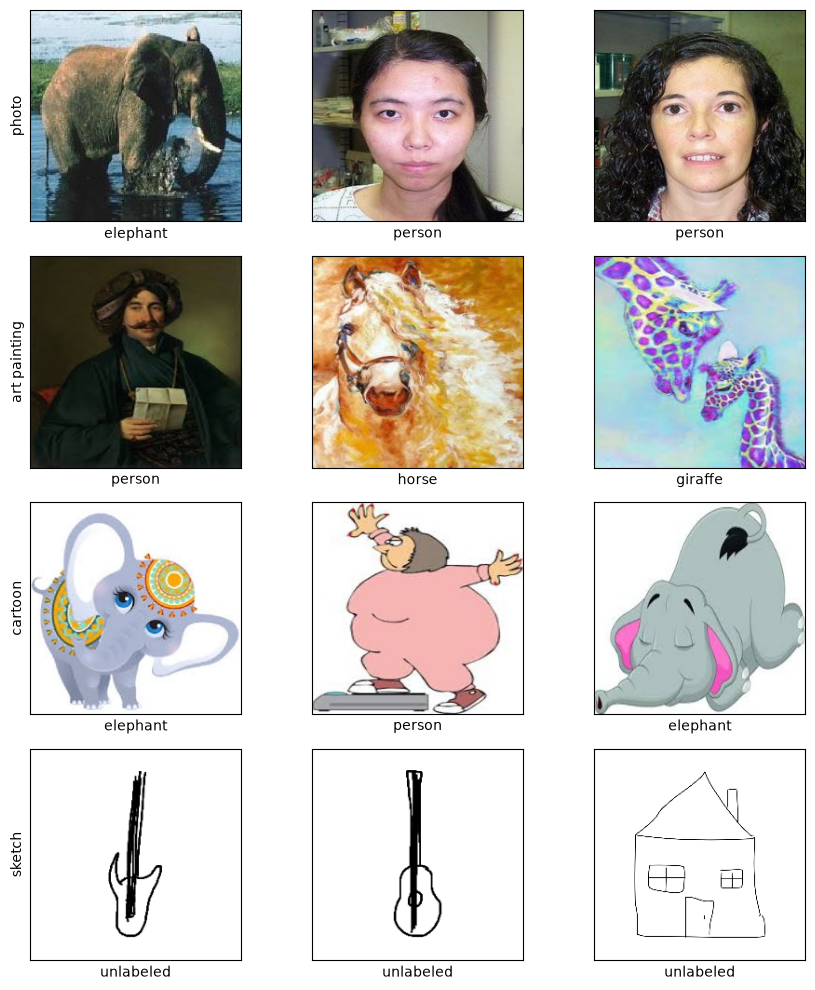

In [5]:
sample_rng = np.random.default_rng(SEED)
display_domains = (*SOURCE_DOMAINS, TARGET_DOMAIN)
samples_per_domain = 3
fig, axes = plt.subplots(
    len(display_domains), samples_per_domain, figsize=(9, 10), squeeze=False
)
for row, domain in enumerate(display_domains):
    dataset = reference_sets[domain]
    if domain in SOURCE_DOMAINS:
        eligible_indices = np.asarray(
            split_manifest["domains"][domain]["train_indices"], dtype=int
        )
    else:
        eligible_indices = np.arange(len(dataset))
    chosen_indices = sample_rng.choice(
        eligible_indices, size=samples_per_domain, replace=False
    )
    for column, sample_index in enumerate(chosen_indices):
        sample_record = dataset.samples[int(sample_index)]
        image_path = sample_record[0]
        display_label = (
            CLASS_NAMES[sample_record[1]] if domain in SOURCE_DOMAINS else "unlabeled"
        )
        with Image.open(image_path) as image:
            axes[row, column].imshow(image.convert("RGB"))
        axes[row, column].set_xticks([])
        axes[row, column].set_yticks([])
        axes[row, column].set_xlabel(display_label)
        if column == 0:
            axes[row, column].set_ylabel(domain.replace("_", " "))
emit_figure(
    fig,
    "Representative PACS samples from each domain before training",
    RESULTS_DIR / "pacs_samples.png",
)


Figure: Representative dog, guitar, and house samples across all domains
Figure: Representative dog, guitar, and house samples across all domains


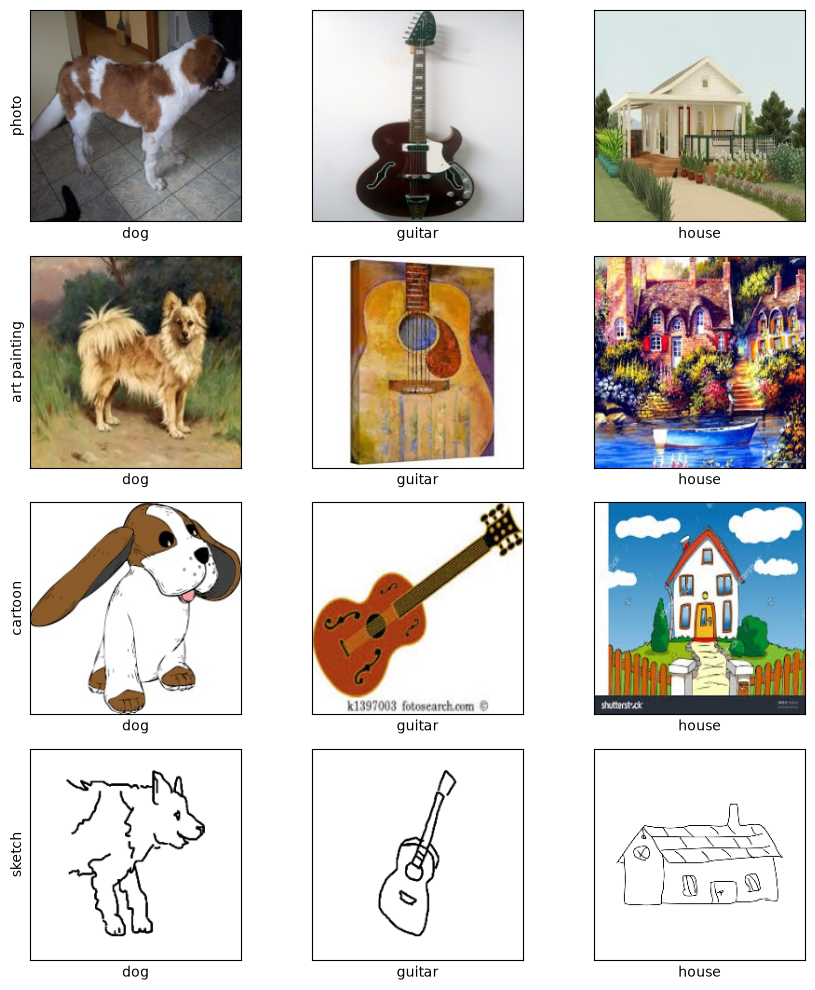

In [6]:
target_class_names = ["dog", "guitar", "house"]
class_name_to_idx = {name: idx for idx, name in enumerate(CLASS_NAMES)}
target_class_indices = [class_name_to_idx[c] for c in target_class_names]

samples_per_domain = len(target_class_names)
fig, axes = plt.subplots(
    len(display_domains), samples_per_domain, figsize=(9, 10), squeeze=False
)

for row, domain in enumerate(display_domains):
    dataset = reference_sets[domain]
    if domain in SOURCE_DOMAINS:
        eligible_indices = np.asarray(
            split_manifest["domains"][domain]["train_indices"], dtype=int
        )
    else:
        eligible_indices = np.arange(len(dataset))
        
    for column, class_idx in enumerate(target_class_indices):
        # Find eligible indices that match the specific target class
        matching_indices = [
            int(idx) for idx in eligible_indices 
            if dataset.samples[int(idx)][1] == class_idx
        ]
        
        # Select a random sample from the matching class, with a fallback if empty
        if matching_indices:
            sample_index = sample_rng.choice(matching_indices)
        else:
            sample_index = sample_rng.choice(eligible_indices)
            
        sample_record = dataset.samples[int(sample_index)]
        image_path = sample_record[0]
        display_label = CLASS_NAMES[sample_record[1]]
        
        with Image.open(image_path) as image:
            axes[row, column].imshow(image.convert("RGB"))
        axes[row, column].set_xticks([])
        axes[row, column].set_yticks([])
        axes[row, column].set_xlabel(display_label)
        if column == 0:
            axes[row, column].set_ylabel(domain.replace("_", " "))

emit_figure(
    fig,
    "Representative dog, guitar, and house samples across all domains",
    RESULTS_DIR / "pacs_samples_by_class.png",
)

### Exact domain-balanced batches

Each update concatenates 8 examples from each source domain. Adaptation methods additionally receive exactly 24 unlabeled Sketch examples. Loaders drop incomplete minibatches and are restarted independently when exhausted, so every update is exactly 24 source / 24 target while the longest source domain determines the number of updates per source epoch. Source-only uses the identical source stream and never constructs or reads a target loader.


In [7]:
class RestartingLoader:
    def __init__(self, loader: DataLoader):
        self.loader = loader
        self.iterator = iter(loader)
    def next(self):
        try:
            return next(self.iterator)
        except StopIteration:
            self.iterator = iter(self.loader)
            return next(self.iterator)

@dataclass
class TrainStreams:
    source: Dict[str, RestartingLoader]
    target: Optional[RestartingLoader]
    steps_per_epoch: int

def make_train_streams(include_target: bool, seed: int = SEED) -> TrainStreams:
    streams = {}
    for offset, domain in enumerate(SOURCE_DOMAINS):
        generator = torch.Generator().manual_seed(seed + offset)
        loader = make_loader(
            source_train_sets[domain],
            batch_size=SOURCE_BATCH_PER_DOMAIN,
            shuffle=True,
            drop_last=True,
            generator=generator,
        )
        if len(loader) == 0:
            raise ValueError(f"{domain} has fewer than {SOURCE_BATCH_PER_DOMAIN} training examples")
        streams[domain] = RestartingLoader(loader)

    target_stream = None
    if include_target:
        generator = torch.Generator().manual_seed(seed + 100)
        target_loader = make_loader(
            target_adaptation_set,
            batch_size=TARGET_BATCH_SIZE,
            shuffle=True,
            drop_last=True,
            generator=generator,
        )
        if len(target_loader) == 0:
            raise ValueError(f"Target domain has fewer than {TARGET_BATCH_SIZE} examples")
        target_stream = RestartingLoader(target_loader)

    steps = max(math.ceil(len(source_train_sets[d]) / SOURCE_BATCH_PER_DOMAIN)
                for d in SOURCE_DOMAINS)
    return TrainStreams(streams, target_stream, steps)

def next_balanced_batch(streams: TrainStreams):
    images, labels = [], []
    for domain in SOURCE_DOMAINS:
        x_domain, y_domain = streams.source[domain].next()
        if x_domain.shape[0] != SOURCE_BATCH_PER_DOMAIN:
            raise RuntimeError("Source loader violated the exact domain batch size.")
        images.append(x_domain)
        labels.append(y_domain)
    x_source = torch.cat(images).to(
        DEVICE, non_blocking=True, memory_format=torch.channels_last
    )
    y_source = torch.cat(labels).to(DEVICE, non_blocking=True)
    x_target = None
    if streams.target is not None:
        x_target = streams.target.next()
        if x_target.shape[0] != TARGET_BATCH_SIZE:
            raise RuntimeError("Target loader violated the exact target batch size.")
        x_target = x_target.to(
            DEVICE, non_blocking=True, memory_format=torch.channels_last
        )
    return x_source, y_source, x_target


## 3. Shared model components and adaptation losses

All methods fine-tune the complete ImageNet-pretrained ResNet-18 and a fresh 7-class head. DAN uses a three-bandwidth RBF kernel MMD on the 512-dimensional pre-classifier feature. DANN and CDAN use the same 256-unit discriminator and gradient-reversal implementation.


In [8]:
class ResNet18Adapter(nn.Module):
    def __init__(self):
        super().__init__()
        network = resnet18(weights=weights)
        feature_dim = network.fc.in_features
        network.fc = nn.Identity()
        self.backbone = network
        self.classifier = nn.Linear(feature_dim, NUM_CLASSES)
        self.feature_dim = feature_dim

    def forward(self, x):
        features = self.backbone(x)
        logits = self.classifier(features)
        return logits, features

class GradientReversalFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        return x.view_as(x)
    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.alpha * grad_output, None

def gradient_reverse(x, alpha: float):
    return GradientReversalFunction.apply(x, alpha)

class DomainDiscriminator(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, 2),
        )
    def forward(self, x):
        return self.network(x)

def dann_alpha(progress: float, ceiling: float = 1.0) -> float:
    return ceiling * (2.0 / (1.0 + math.exp(-10.0 * progress)) - 1.0)

def multi_kernel_mmd(source_features, target_features):
    combined = torch.cat([source_features, target_features], dim=0).float()
    pairwise_sq = torch.cdist(combined, combined, p=2).pow(2)
    nonzero_distances = torch.pdist(combined, p=2).pow(2)
    median_sq = nonzero_distances.median().detach().clamp_min(1e-6)
    kernel = torch.zeros_like(pairwise_sq)
    for multiplier in (0.5, 1.0, 2.0):
        bandwidth = multiplier * median_sq
        kernel = kernel + torch.exp(-pairwise_sq / (2.0 * bandwidth))
    n_source = source_features.shape[0]
    k_ss = kernel[:n_source, :n_source]
    k_tt = kernel[n_source:, n_source:]
    k_st = kernel[:n_source, n_source:]
    # Biased Gram-matrix estimator is stable and non-negative for minibatches.
    return k_ss.mean() + k_tt.mean() - 2.0 * k_st.mean()

def cdan_joint(features, logits):
    probabilities = logits.softmax(dim=1)
    # vec(f outer p): [batch, 512, 7] -> [batch, 3584].
    return (features.unsqueeze(2) * probabilities.unsqueeze(1)).flatten(1)


## 4. Shared evaluation and generic training loop

Training progress for GRL is `global_step / (MAX_EPOCHS * steps_per_epoch - 1)`, clipped to [0, 1]. It therefore follows the same schedule regardless of early stopping. An epoch is an improvement only when mean source-validation macro-F1 is strictly greater than the previous best; deterministic equality retains the earlier checkpoint.

After every `model.train()`, only BatchNorm modules are returned to eval mode. Their affine parameters remain in the optimizer and train normally. All neural-network forwards—including validation and cached feature extraction—run inside the shared autocast context.


In [9]:
@torch.no_grad()
def evaluate_labeled(model: nn.Module, dataset: Dataset, return_arrays: bool = False):
    model.eval()
    loader = make_loader(dataset, batch_size=EVAL_BATCH_SIZE, shuffle=False, drop_last=False)
    truths, predictions, logits_all = [], [], []
    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=True, memory_format=torch.channels_last)
        with amp_context():
            logits, _ = model(images)
        if not torch.isfinite(logits).all():
            raise FloatingPointError(
                "Non-finite evaluation logits detected. This checkpoint diverged; "
                "retrain it with the current bfloat16-preferred AMP configuration."
            )
        truths.append(labels.numpy())
        predictions.append(logits.argmax(dim=1).cpu().numpy())
        if return_arrays:
            logits_all.append(logits.float().cpu().numpy())
    y_true = np.concatenate(truths)
    y_pred = np.concatenate(predictions)
    result = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
    }
    if return_arrays:
        result.update(y_true=y_true, y_pred=y_pred, logits=np.concatenate(logits_all))
    return result

def evaluate_sources(model: nn.Module):
    per_domain = {domain: evaluate_labeled(model, source_val_sets[domain])
                  for domain in SOURCE_DOMAINS}
    return per_domain, float(np.mean([v["macro_f1"] for v in per_domain.values()]))

def checkpoint_stem(method_name: str) -> str:
    return method_name.lower().replace("-", "_").replace(".", "p")

def save_training_curves(history: list[dict], method_name: str) -> None:
    frame = pd.DataFrame(history)
    adaptation_values = frame["adaptation_loss"].to_numpy(dtype=float)
    if not np.isfinite(adaptation_values).all():
        raise FloatingPointError(
            f"{method_name} has non-finite adaptation loss history; "
            "the run diverged and cannot produce a meaningful curve."
        )
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(frame["epoch"], frame["classification_loss"], marker="o", label="classification")
    axes[0].set(xlabel="Epoch", ylabel="Cross-entropy loss")
    axes[0].grid(alpha=0.25)
    axes[1].plot(frame["epoch"], frame["adaptation_loss"], marker="o", color="tab:orange",
                 label="alignment/domain")
    axes[1].set(xlabel="Epoch", ylabel="Adaptation loss")
    axes[1].grid(alpha=0.25)
    if not np.allclose(adaptation_values, 0.0):
        axes[1].legend()
    axes[0].legend()
    emit_figure(
        fig,
        f"{method_name} classification and adaptation training curves",
        CURVE_DIR / f"{checkpoint_stem(method_name)}.png",
    )

def train_method(
    method: str,
    *,
    run_name: Optional[str] = None,
    lambda_mmd: float = 1.0,
    grl_ceiling: float = 1.0,
):
    method = method.lower()
    if method not in {"source_only", "dan", "dann", "cdan"}:
        raise ValueError(f"Unknown method: {method}")
    run_name = run_name or method
    seed_everything(SEED)
    model = ResNet18Adapter().to(DEVICE, memory_format=torch.channels_last)
    discriminator = None
    if method == "dann":
        discriminator = DomainDiscriminator(model.feature_dim).to(DEVICE)
    elif method == "cdan":
        discriminator = DomainDiscriminator(model.feature_dim * NUM_CLASSES).to(DEVICE)

    parameters = list(model.parameters())
    if discriminator is not None:
        parameters += list(discriminator.parameters())
    optimizer = torch.optim.AdamW(parameters, lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scaler = make_grad_scaler()
    streams = make_train_streams(include_target=(method != "source_only"), seed=SEED)
    total_steps = MAX_EPOCHS * streams.steps_per_epoch
    best_f1, stale_epochs, global_step = -math.inf, 0, 0
    history = []
    checkpoint_path = CHECKPOINT_DIR / f"{checkpoint_stem(run_name)}_seed{SEED}.pt"
    metadata_path = checkpoint_path.with_suffix(".json")

    for epoch in range(1, MAX_EPOCHS + 1):
        train_mode_with_frozen_bn(model, discriminator)
        cls_sum, adaptation_sum = 0.0, 0.0
        batch_bar = tqdm(
            range(streams.steps_per_epoch),
            desc=f"{run_name} | epoch {epoch:02d}/{MAX_EPOCHS}",
            unit="batch",
            leave=True,
        )
        for batch_index in batch_bar:
            x_source, y_source, x_target = next_balanced_batch(streams)
            optimizer.zero_grad(set_to_none=True)
            progress = global_step / max(total_steps - 1, 1)
            alpha = dann_alpha(progress, grl_ceiling)

            with amp_context():
                if method == "source_only":
                    source_logits, _ = model(x_source)
                    adaptation_loss = source_logits.new_zeros(())
                else:
                    all_images = torch.cat([x_source, x_target], dim=0)
                    all_logits, all_features = model(all_images)
                    source_logits = all_logits[:x_source.shape[0]]
                    source_features = all_features[:x_source.shape[0]]
                    target_features = all_features[x_source.shape[0]:]
                    if method == "dan":
                        adaptation_loss = lambda_mmd * multi_kernel_mmd(
                            source_features, target_features
                        )
                    else:
                        domain_labels = torch.cat([
                            torch.zeros(x_source.shape[0], dtype=torch.long, device=DEVICE),
                            torch.ones(x_target.shape[0], dtype=torch.long, device=DEVICE),
                        ])
                        if method == "dann":
                            discriminator_input = all_features
                        else:
                            # Neither features nor probabilities are detached.
                            discriminator_input = cdan_joint(all_features, all_logits)
                        domain_logits = discriminator(
                            gradient_reverse(discriminator_input, alpha)
                        )
                        adaptation_loss = F.cross_entropy(domain_logits, domain_labels)

                classification_loss = F.cross_entropy(source_logits, y_source)
                loss = classification_loss + adaptation_loss

            if not torch.isfinite(loss):
                raise FloatingPointError(
                    f"{run_name} produced a non-finite loss at epoch {epoch}, "
                    f"step {global_step}, AMP dtype {AMP_DTYPE}. No invalid checkpoint will be saved."
                )
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            cls_sum += float(classification_loss.detach())
            adaptation_sum += float(adaptation_loss.detach())
            global_step += 1
            completed_batches = batch_index + 1
            batch_bar.set_postfix(
                cls=f"{cls_sum / completed_batches:.4f}",
                adapt=f"{adaptation_sum / completed_batches:.4f}",
            )

        source_metrics, mean_source_f1 = evaluate_sources(model)
        epoch_record = {
            "epoch": epoch,
            "classification_loss": cls_sum / streams.steps_per_epoch,
            "adaptation_loss": adaptation_sum / streams.steps_per_epoch,
            "mean_source_val_f1": mean_source_f1,
        }
        history.append(epoch_record)
        tqdm.write(
            f"{run_name} | epoch {epoch:02d}: "
            f"cls={epoch_record['classification_loss']:.4f}, "
            f"adapt={epoch_record['adaptation_loss']:.4f}, "
            f"source-val macro-F1={mean_source_f1:.4f}"
        )

        if mean_source_f1 > best_f1:
            best_f1, stale_epochs = mean_source_f1, 0
            payload = {
                "model_state": model.state_dict(),
                "discriminator_state": (
                    discriminator.state_dict() if discriminator is not None else None
                ),
                "method": method,
                "run_name": run_name,
                "epoch": epoch,
                "seed": SEED,
                "class_to_idx": class_to_idx,
                "source_val": source_metrics,
                "mean_source_val_macro_f1": mean_source_f1,
                "lambda_mmd": lambda_mmd,
                "grl_ceiling": grl_ceiling,
                "amp_dtype": str(AMP_DTYPE),
            }
            torch.save(payload, checkpoint_path)
            json_dump({k: v for k, v in payload.items()
                       if k not in {"model_state", "discriminator_state"}}, metadata_path)
        else:
            stale_epochs += 1
            if stale_epochs >= PATIENCE:
                tqdm.write(f"{run_name}: early stopping after {epoch} epochs.")
                break

    saved = torch.load(checkpoint_path, map_location=DEVICE)
    model.load_state_dict(saved["model_state"])
    if discriminator is not None and saved["discriminator_state"] is not None:
        discriminator.load_state_dict(saved["discriminator_state"])
    model.eval()
    if discriminator is not None:
        discriminator.eval()
    save_training_curves(history, run_name)
    pd.DataFrame(history).to_csv(
        CURVE_DIR / f"{checkpoint_stem(run_name)}.csv", index=False
    )
    return {"model": model, "discriminator": discriminator, "checkpoint": saved,
            "history": history, "checkpoint_path": checkpoint_path}


## 5. Train the four required methods

These calls use identical initialization, source split, augmentations, optimizer, training budget, source checkpoint criterion, and batch construction. Source-only never requests a target stream. The saved Source-only path is stable for Task 3: `results/checkpoints/source_only_seed6304.pt`.

### Pre-registered controlled study: DAN alignment weight

The one controlled study varies $\lambda_{\mathrm{MMD}} \in \{0.1, 1, 10\}$. **Hypothesis, stated before any study run or target-label evaluation:** increasing the weight from 0.1 to 1 should reduce domain separability and may improve Sketch recognition by encouraging transferable features, with a modest source-performance cost. At 10, alignment is expected to dominate class discrimination: separability may fall further, but both source performance and target recognition may degrade. These expectations are not used for checkpoint selection. The main comparison remains fixed at $\lambda_{\mathrm{MMD}}=1$, regardless of study results.

The $\lambda=1$ condition is the main DAN run. The 0.1 and 10 runs use identical settings apart from the named alignment weight. All six checkpoints (four main plus two additional study conditions) are frozen using source validation before the first code cell that reads a Sketch label.


source_only | epoch 01/30:   0%|          | 0/235 [00:00<?, ?batch/s]

source_only | epoch 01: cls=0.5028, adapt=0.0000, source-val macro-F1=0.8851


source_only | epoch 02/30:   0%|          | 0/235 [00:00<?, ?batch/s]

source_only | epoch 02: cls=0.2007, adapt=0.0000, source-val macro-F1=0.8718


source_only | epoch 03/30:   0%|          | 0/235 [00:00<?, ?batch/s]

...

source_only | epoch 14: cls=0.0298, adapt=0.0000, source-val macro-F1=0.9426


source_only | epoch 15/30:   0%|          | 0/235 [00:00<?, ?batch/s]

source_only | epoch 15: cls=0.0442, adapt=0.0000, source-val macro-F1=0.9237


source_only | epoch 16/30:   0%|          | 0/235 [00:00<?, ?batch/s]

source_only | epoch 16: cls=0.0349, adapt=0.0000, source-val macro-F1=0.9371
source_only: early stopping after 16 epochs.
Figure: source_only classification and adaptation training curves
Figure: source_only classification and adaptation training curves


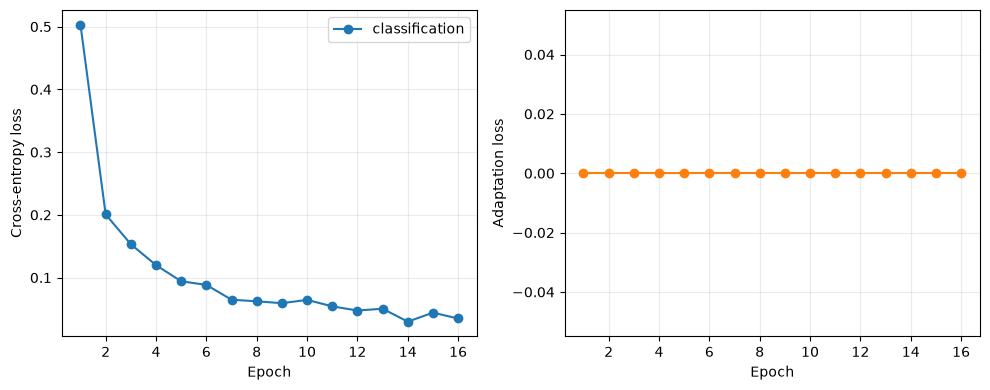

dan | epoch 01/30:   0%|          | 0/235 [00:00<?, ?batch/s]

dan | epoch 01: cls=1.8717, adapt=0.1983, source-val macro-F1=0.0361


dan | epoch 02/30:   0%|          | 0/235 [00:00<?, ?batch/s]

dan | epoch 02: cls=1.9396, adapt=0.1545, source-val macro-F1=0.0361


dan | epoch 03/30:   0%|          | 0/235 [00:00<?, ?batch/s]

...

dan | epoch 06: cls=1.9321, adapt=0.0442, source-val macro-F1=0.0507


dan | epoch 07/30:   0%|          | 0/235 [00:00<?, ?batch/s]

dan | epoch 07: cls=1.9310, adapt=0.0506, source-val macro-F1=0.0507


dan | epoch 08/30:   0%|          | 0/235 [00:00<?, ?batch/s]

dan | epoch 08: cls=1.9294, adapt=0.0379, source-val macro-F1=0.0507
dan: early stopping after 8 epochs.
Figure: dan classification and adaptation training curves
Figure: dan classification and adaptation training curves


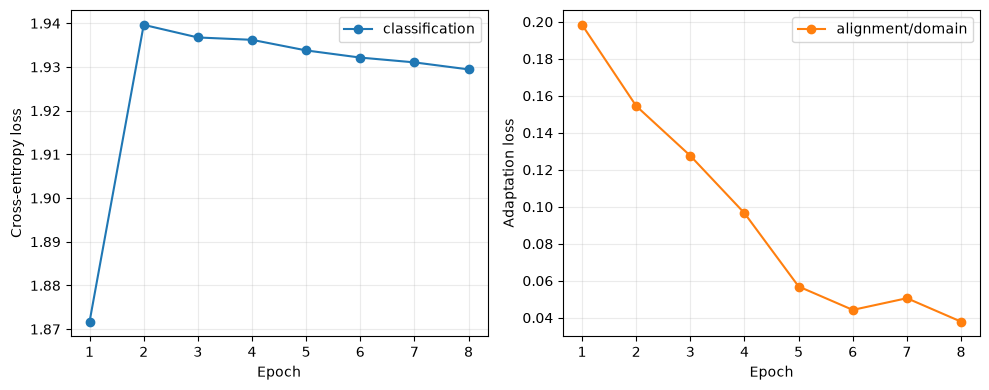

dann | epoch 01/30:   0%|          | 0/235 [00:00<?, ?batch/s]

dann | epoch 01: cls=16662.8048, adapt=238030.7013, source-val macro-F1=0.0361


dann | epoch 02/30:   0%|          | 0/235 [00:00<?, ?batch/s]

dann | epoch 02: cls=4436.2578, adapt=14923.4793, source-val macro-F1=0.0418


dann | epoch 03/30:   0%|          | 0/235 [00:00<?, ?batch/s]

...

dann | epoch 09: cls=3.4496, adapt=2.8533, source-val macro-F1=0.1008


dann | epoch 10/30:   0%|          | 0/235 [00:00<?, ?batch/s]

dann | epoch 10: cls=85.4075, adapt=24.0330, source-val macro-F1=0.0556


dann | epoch 11/30:   0%|          | 0/235 [00:00<?, ?batch/s]

dann | epoch 11: cls=11.4660, adapt=1.6492, source-val macro-F1=0.0342
dann: early stopping after 11 epochs.
Figure: dann classification and adaptation training curves
Figure: dann classification and adaptation training curves


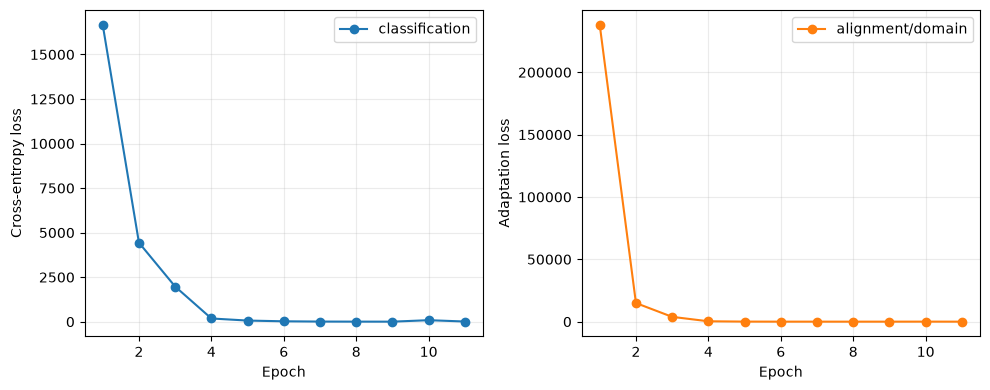

cdan | epoch 01/30:   0%|          | 0/235 [00:00<?, ?batch/s]

cdan | epoch 01: cls=0.5119, adapt=0.4927, source-val macro-F1=0.9101


cdan | epoch 02/30:   0%|          | 0/235 [00:00<?, ?batch/s]

cdan | epoch 02: cls=0.2399, adapt=0.5982, source-val macro-F1=0.8703


cdan | epoch 03/30:   0%|          | 0/235 [00:00<?, ?batch/s]

...

cdan | epoch 12: cls=0.0802, adapt=0.6911, source-val macro-F1=0.9063


cdan | epoch 13/30:   0%|          | 0/235 [00:00<?, ?batch/s]

cdan | epoch 13: cls=0.0731, adapt=0.6916, source-val macro-F1=0.9129


cdan | epoch 14/30:   0%|          | 0/235 [00:00<?, ?batch/s]

cdan | epoch 14: cls=0.0683, adapt=0.6895, source-val macro-F1=0.9244
cdan: early stopping after 14 epochs.
Figure: cdan classification and adaptation training curves
Figure: cdan classification and adaptation training curves


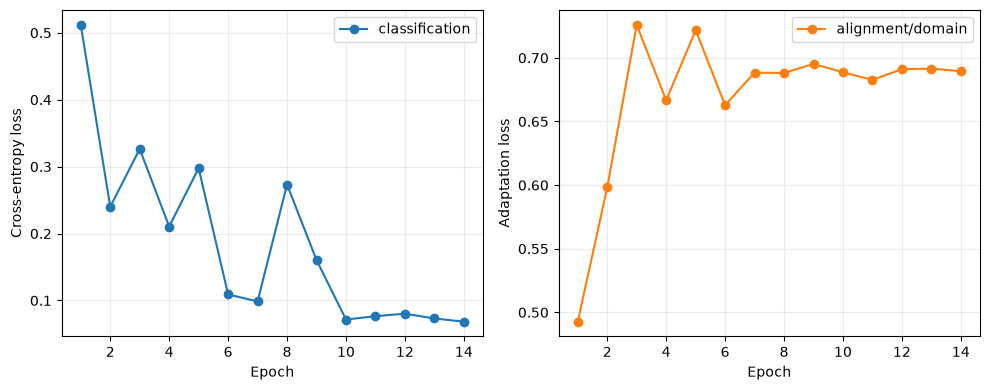

dan_lambda_0.1 | epoch 01/30:   0%|          | 0/235 [00:00<?, ?batch/s]

dan_lambda_0.1 | epoch 01: cls=0.4999, adapt=0.0267, source-val macro-F1=0.9087


dan_lambda_0.1 | epoch 02/30:   0%|          | 0/235 [00:00<?, ?batch/s]

dan_lambda_0.1 | epoch 02: cls=0.1938, adapt=0.0176, source-val macro-F1=0.9001


dan_lambda_0.1 | epoch 03/30:   0%|          | 0/235 [00:00<?, ?batch/s]

...

dan_lambda_0.1 | epoch 16: cls=0.0576, adapt=0.0147, source-val macro-F1=0.9331


dan_lambda_0.1 | epoch 17/30:   0%|          | 0/235 [00:00<?, ?batch/s]

dan_lambda_0.1 | epoch 17: cls=0.0269, adapt=0.0127, source-val macro-F1=0.9311


dan_lambda_0.1 | epoch 18/30:   0%|          | 0/235 [00:00<?, ?batch/s]

dan_lambda_0.1 | epoch 18: cls=0.0123, adapt=0.0117, source-val macro-F1=0.9493
dan_lambda_0.1: early stopping after 18 epochs.
Figure: dan_lambda_0.1 classification and adaptation training curves
Figure: dan_lambda_0.1 classification and adaptation training curves


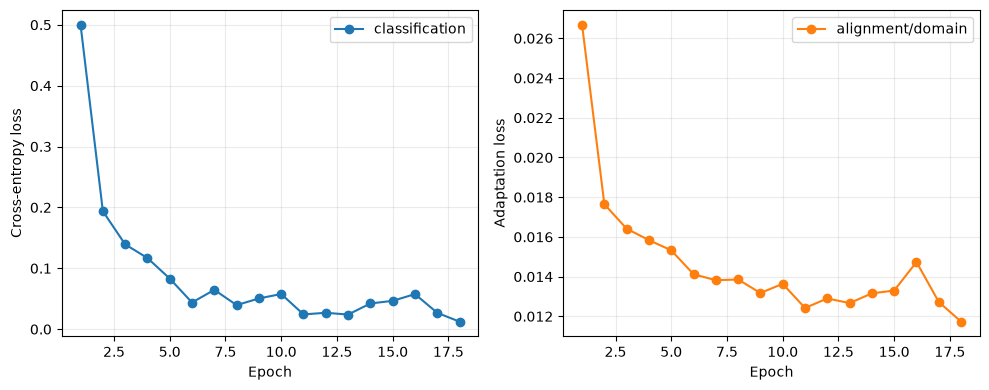

dan_lambda_10 | epoch 01/30:   0%|          | 0/235 [00:00<?, ?batch/s]

dan_lambda_10 | epoch 01: cls=1.9473, adapt=2.0300, source-val macro-F1=0.0507


dan_lambda_10 | epoch 02/30:   0%|          | 0/235 [00:00<?, ?batch/s]

dan_lambda_10 | epoch 02: cls=1.9397, adapt=1.6374, source-val macro-F1=0.0507


dan_lambda_10 | epoch 03/30:   0%|          | 0/235 [00:00<?, ?batch/s]

...

dan_lambda_10 | epoch 04: cls=1.9379, adapt=1.2965, source-val macro-F1=0.0507


dan_lambda_10 | epoch 05/30:   0%|          | 0/235 [00:00<?, ?batch/s]

dan_lambda_10 | epoch 05: cls=1.9358, adapt=0.0743, source-val macro-F1=0.0507


dan_lambda_10 | epoch 06/30:   0%|          | 0/235 [00:00<?, ?batch/s]

dan_lambda_10 | epoch 06: cls=1.9339, adapt=0.0145, source-val macro-F1=0.0507
dan_lambda_10: early stopping after 6 epochs.
Figure: dan_lambda_10 classification and adaptation training curves
Figure: dan_lambda_10 classification and adaptation training curves


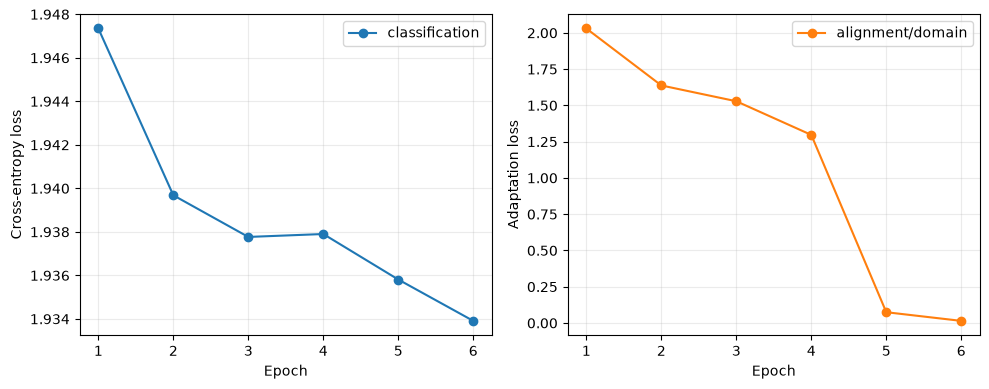

source_only selected epoch: 11 per-source validation: {'photo': {'accuracy': 0.9670658682634731, 'macro_f1': 0.9606577614803063}, 'art_painting': {'accuracy': 0.9243902439024391, 'macro_f1': 0.930780082602648}, 'cartoon': {'accuracy': 0.9488272921108742, 'macro_f1': 0.9526656243406183}} mean source macro-F1: 0.9480344894745243
dan selected epoch: 3 per-source validation: {'photo': {'accuracy': 0.25748502994011974, 'macro_f1': 0.058503401360544216}, 'art_painting': {'accuracy': 0.21951219512195122, 'macro_f1': 0.05142857142857143}, 'cartoon': {'accuracy': 0.17270788912579957, 'macro_f1': 0.04207792207792208}} mean source macro-F1: 0.05066996495567924
dann selected epoch: 6 per-source validation: {'photo': {'accuracy': 0.17964071856287425, 'macro_f1': 0.17089445433197561}, 'art_painting': {'accuracy': 0.15609756097560976, 'macro_f1': 0.14369296947026378}, 'cartoon': {'accuracy': 0.16204690831556504, 'macro_f1': 0.14503517988152334}} mean source macro-F1: 0.15320753456125424
cdan selected

In [10]:
runs = {}
runs["source_only"] = train_method("source_only")
runs["dan"] = train_method("dan", lambda_mmd=1.0)
runs["dann"] = train_method("dann", grl_ceiling=1.0)
runs["cdan"] = train_method("cdan", grl_ceiling=1.0)

study_runs = {
    0.1: train_method("dan", run_name="dan_lambda_0.1", lambda_mmd=0.1),
    1.0: runs["dan"],
    10.0: train_method("dan", run_name="dan_lambda_10", lambda_mmd=10.0),
}

for name, run in runs.items():
    checkpoint = run["checkpoint"]
    print(
        name,
        "selected epoch:", checkpoint["epoch"],
        "per-source validation:", checkpoint["source_val"],
        "mean source macro-F1:", checkpoint["mean_source_val_macro_f1"],
    )


## 6. Common final evaluation

All main checkpoints are now frozen based solely on source validation macro-F1. The following cells are the first code that uses Sketch labels.

For domain separability, each frozen backbone's source-validation and target features are cached. Equal counts are sampled with seed 6304, then a stratified 70/30 split trains a balanced logistic regression with `C=1`. Held-out accuracy near 0.5 indicates domain-invariant features.


In [11]:
def file_sha256_prefix(path: Path, length: int = 12) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()[:length]

@torch.no_grad()
def extract_features(model: nn.Module, dataset: Dataset):
    model.eval()
    loader = make_loader(dataset, batch_size=EVAL_BATCH_SIZE, shuffle=False, drop_last=False)
    features, labels = [], []
    for images, batch_labels in loader:
        images = images.to(DEVICE, non_blocking=True, memory_format=torch.channels_last)
        with amp_context():
            _, batch_features = model(images)
        batch_features = batch_features.float()
        if not torch.isfinite(batch_features).all():
            raise FloatingPointError(
                "Non-finite backbone features detected. This checkpoint diverged; "
                "retrain it with the current bfloat16-preferred AMP configuration."
            )
        features.append(batch_features.cpu().numpy())
        labels.append(np.asarray(batch_labels))
    return np.concatenate(features), np.concatenate(labels)

def cached_probe_features(method_name: str, run: dict):
    signature = file_sha256_prefix(run["checkpoint_path"])
    path = CACHE_DIR / f"{checkpoint_stem(method_name)}_{signature}_probe_features.npz"
    if path.exists():
        cached = np.load(path)
        source_features, target_features = cached["source_features"], cached["target_features"]
        if np.isfinite(source_features).all() and np.isfinite(target_features).all():
            return source_features, target_features
        raise FloatingPointError(
            f"Cached features for {method_name} contain NaN/Inf ({path}). "
            "The associated checkpoint diverged and must be retrained."
        )
    source_features = []
    for domain in SOURCE_DOMAINS:
        domain_features, _ = extract_features(run["model"], source_val_sets[domain])
        source_features.append(domain_features)
    source_features = np.concatenate(source_features)
    target_features, _ = extract_features(run["model"], target_eval_set)
    np.savez_compressed(
        path, source_features=source_features, target_features=target_features
    )
    return source_features, target_features

def domain_separability_score(method_name: str, run: dict) -> float:
    source_features, target_features = cached_probe_features(method_name, run)
    count = min(len(source_features), len(target_features))
    rng = np.random.default_rng(SEED)
    source_idx = rng.choice(len(source_features), size=count, replace=False)
    target_idx = rng.choice(len(target_features), size=count, replace=False)
    x = np.concatenate([source_features[source_idx], target_features[target_idx]])
    y = np.concatenate([np.zeros(count, dtype=int), np.ones(count, dtype=int)])
    x_train, x_test, y_train, y_test = train_test_split(
        x, y, test_size=0.30, random_state=SEED, stratify=y
    )
    probe = LogisticRegression(
        C=1.0, class_weight="balanced", max_iter=2000, random_state=SEED
    )
    probe.fit(x_train, y_train)
    return float(accuracy_score(y_test, probe.predict(x_test)))

main_rows = []
target_outputs = {}
for method_name, run in runs.items():
    source_metrics, _ = evaluate_sources(run["model"])
    target_metrics = evaluate_labeled(run["model"], target_eval_set, return_arrays=True)
    target_outputs[method_name] = target_metrics
    row = {"method": method_name}
    for domain in SOURCE_DOMAINS:
        row[f"{domain}_acc"] = source_metrics[domain]["accuracy"]
        row[f"{domain}_f1"] = source_metrics[domain]["macro_f1"]
    row["mean_source_acc"] = float(np.mean(
        [source_metrics[d]["accuracy"] for d in SOURCE_DOMAINS]
    ))
    row["mean_source_f1"] = float(np.mean(
        [source_metrics[d]["macro_f1"] for d in SOURCE_DOMAINS]
    ))
    row["target_acc"] = target_metrics["accuracy"]
    row["target_f1"] = target_metrics["macro_f1"]
    row["domain_separability"] = domain_separability_score(method_name, run)
    main_rows.append(row)

main_comparison = pd.DataFrame(main_rows)
source_only_acc = float(
    main_comparison.loc[main_comparison["method"] == "source_only", "target_acc"].iloc[0]
)
main_comparison["target_acc_delta_vs_source_only"] = (
    main_comparison["target_acc"] - source_only_acc
)
main_comparison.to_csv(RESULTS_DIR / "main_comparison_table.csv", index=False)
display(main_comparison)


,method,photo_acc,photo_f1,art_painting_acc,art_painting_f1,cartoon_acc,cartoon_f1,mean_source_acc,mean_source_f1,target_acc,target_f1,domain_separability,target_acc_delta_vs_source_only
0,source_only,0.967066,0.960658,0.924390,0.930780,0.948827,0.952666,0.946761,0.948034,0.701196,0.692346,0.997253,0.000000
1,dan,0.257485,0.058503,0.219512,0.051429,0.172708,0.042078,0.216568,0.050670,0.040723,0.011180,0.500000,-0.660473
2,dann,0.179641,0.170894,0.156098,0.143693,0.162047,0.145035,0.165928,0.153208,0.192415,0.135731,0.758242,-0.508781
3,cdan,0.949102,0.944524,0.895122,0.896321,0.948827,0.955892,0.931017,0.932246,0.781115,0.764186,0.975275,0.079919


Figure: Mean source-validation and Sketch target accuracy by adaptation method
Figure: Mean source-validation and Sketch target accuracy by adaptation method


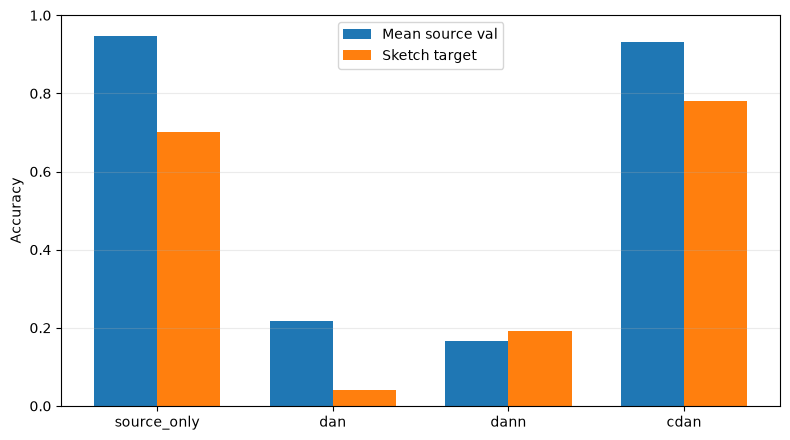

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.5))
positions = np.arange(len(main_comparison))
width = 0.36
ax.bar(positions - width / 2, main_comparison["mean_source_acc"], width, label="Mean source val")
ax.bar(positions + width / 2, main_comparison["target_acc"], width, label="Sketch target")
ax.set_xticks(positions, main_comparison["method"])
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(axis="y", alpha=0.25)
emit_figure(
    fig,
    "Mean source-validation and Sketch target accuracy by adaptation method",
    RESULTS_DIR / "main_accuracy_comparison.png",
)


### Per-class target accuracy and dominant confusions

The long-form CSV records accuracy, support, and change from Source-only for every method/class pair. Confusion matrices use raw counts. The printed summaries identify each method's largest per-class improvement and degradation and each affected class's dominant incorrect prediction.


,method,class,accuracy,support,delta_vs_source_only,dominant_confusion
0,source_only,dog,0.598446,772,0.000000,elephant (150)
1,source_only,elephant,0.817568,740,0.000000,dog (96)
2,source_only,giraffe,0.523240,753,0.000000,dog (122)
3,source_only,guitar,0.919408,608,0.000000,elephant (37)
4,source_only,horse,0.692402,816,0.000000,dog (139)
5,source_only,house,0.537500,80,0.000000,elephant (19)
6,source_only,person,0.793750,160,0.000000,elephant (19)
7,dan,dog,0.000000,772,-0.598446,person (772)
8,dan,elephant,0.000000,740,-0.817568,person (740)
9,dan,giraffe,0.000000,753,-0.523240,person (753)


dan: largest improvement = person (+0.206), dominant confusion none; largest degradation = guitar (-0.919), dominant confusion person (608)
dann: largest improvement = giraffe (-0.219), dominant confusion dog (316); largest degradation = guitar (-0.895), dominant confusion dog (372)
cdan: largest improvement = house (+0.463), dominant confusion none; largest degradation = guitar (+0.036), dominant confusion elephant (12)
Figure: Sketch target confusion matrix for source_only
Figure: Sketch target confusion matrix for source_only


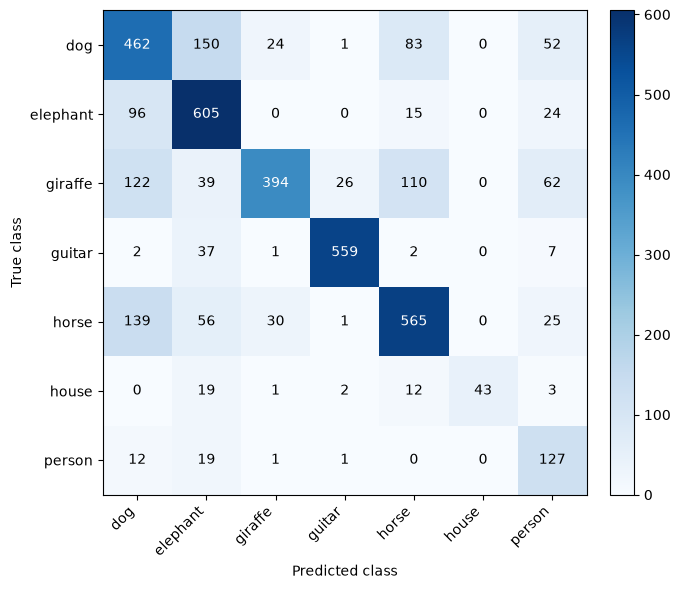

Figure: Sketch target confusion matrix for dan
Figure: Sketch target confusion matrix for dan


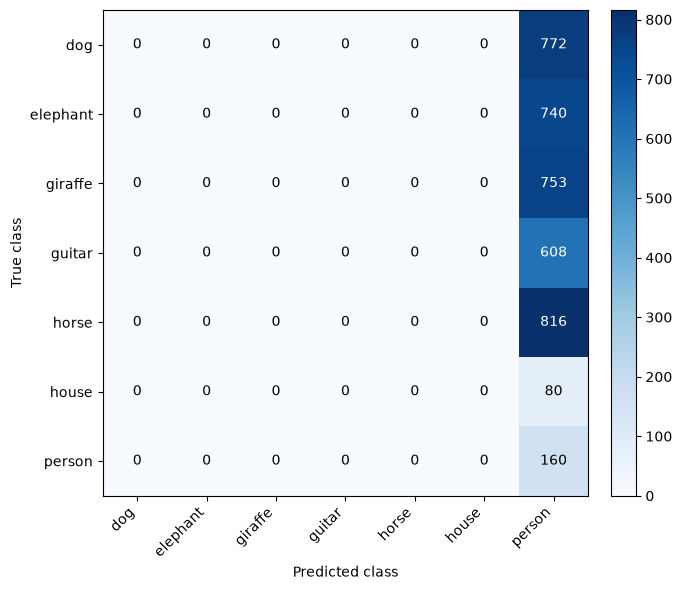

Figure: Sketch target confusion matrix for dann
Figure: Sketch target confusion matrix for dann


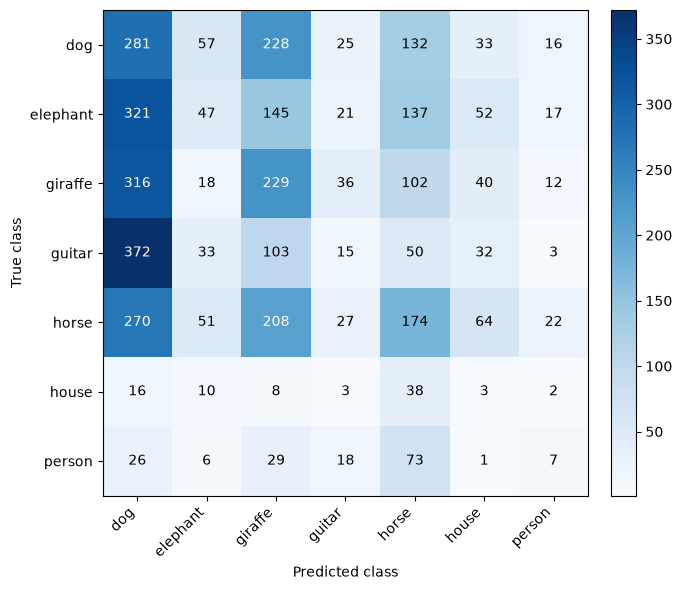

Figure: Sketch target confusion matrix for cdan
Figure: Sketch target confusion matrix for cdan


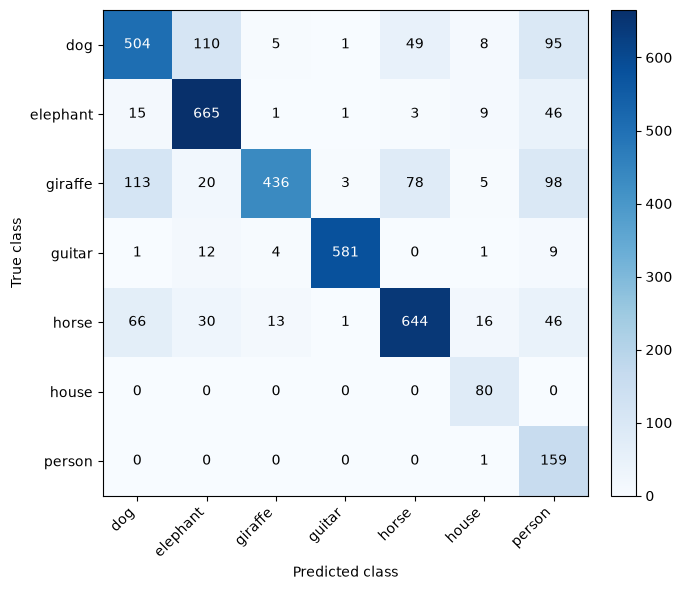

In [13]:
def dominant_confusion(y_true, y_pred, class_index: int) -> str:
    mask = y_true == class_index
    wrong = y_pred[mask & (y_pred != class_index)]
    if len(wrong) == 0:
        return "none"
    counts = np.bincount(wrong, minlength=NUM_CLASSES)
    predicted = int(counts.argmax())
    return f"{CLASS_NAMES[predicted]} ({int(counts[predicted])})"

baseline_output = target_outputs["source_only"]
baseline_class_acc = {}
for class_index, class_name in enumerate(CLASS_NAMES):
    mask = baseline_output["y_true"] == class_index
    baseline_class_acc[class_index] = float(
        (baseline_output["y_pred"][mask] == class_index).mean()
    )

per_class_rows = []
for method_name, output in target_outputs.items():
    for class_index, class_name in enumerate(CLASS_NAMES):
        mask = output["y_true"] == class_index
        class_accuracy = float((output["y_pred"][mask] == class_index).mean())
        per_class_rows.append({
            "method": method_name,
            "class": class_name,
            "accuracy": class_accuracy,
            "support": int(mask.sum()),
            "delta_vs_source_only": class_accuracy - baseline_class_acc[class_index],
            "dominant_confusion": dominant_confusion(
                output["y_true"], output["y_pred"], class_index
            ),
        })

per_class_target = pd.DataFrame(per_class_rows)
per_class_target.to_csv(RESULTS_DIR / "per_class_target_accuracy.csv", index=False)
display(per_class_target)

for method_name in ("dan", "dann", "cdan"):
    subset = per_class_target[per_class_target["method"] == method_name]
    best = subset.loc[subset["delta_vs_source_only"].idxmax()]
    worst = subset.loc[subset["delta_vs_source_only"].idxmin()]
    print(
        f"{method_name}: largest improvement = {best['class']} "
        f"({best['delta_vs_source_only']:+.3f}), dominant confusion {best['dominant_confusion']}; "
        f"largest degradation = {worst['class']} "
        f"({worst['delta_vs_source_only']:+.3f}), dominant confusion {worst['dominant_confusion']}"
    )

for method_name, output in target_outputs.items():
    matrix = confusion_matrix(
        output["y_true"], output["y_pred"], labels=np.arange(NUM_CLASSES)
    )
    fig, ax = plt.subplots(figsize=(7, 6))
    image = ax.imshow(matrix, cmap="Blues")
    ax.set_xticks(np.arange(NUM_CLASSES), CLASS_NAMES, rotation=45, ha="right")
    ax.set_yticks(np.arange(NUM_CLASSES), CLASS_NAMES)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    for row in range(NUM_CLASSES):
        for column in range(NUM_CLASSES):
            ax.text(column, row, int(matrix[row, column]), ha="center", va="center",
                    color="white" if matrix[row, column] > matrix.max() / 2 else "black")
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    emit_figure(
        fig,
        f"Sketch target confusion matrix for {method_name}",
        CONFUSION_DIR / f"{checkpoint_stem(method_name)}.png",
    )


## 7. Controlled design study results: DAN alignment weight

The hypothesis and fixed settings were recorded in Section 5 before training. This section only evaluates the already-frozen study checkpoints.

The $\lambda=1$ row reuses the already-frozen main DAN run. Sketch labels remain descriptive analysis only and do not change the reported main setting.


In [14]:
study_rows = []
for lambda_value, run in study_runs.items():
    source_metrics, _ = evaluate_sources(run["model"])
    # All study checkpoints/settings are frozen before this target-label call.
    target_metrics = evaluate_labeled(run["model"], target_eval_set)
    study_name = f"dan_lambda_{lambda_value:g}"
    study_rows.append({
        "lambda_mmd": lambda_value,
        "mean_source_acc": float(np.mean(
            [source_metrics[d]["accuracy"] for d in SOURCE_DOMAINS]
        )),
        "mean_source_f1": float(np.mean(
            [source_metrics[d]["macro_f1"] for d in SOURCE_DOMAINS]
        )),
        "target_acc": target_metrics["accuracy"],
        "target_f1": target_metrics["macro_f1"],
        "domain_separability": domain_separability_score(study_name, run),
    })

controlled_study = pd.DataFrame(study_rows).sort_values("lambda_mmd")
controlled_study.to_csv(RESULTS_DIR / "controlled_study_results.csv", index=False)
display(controlled_study)


,lambda_mmd,mean_source_acc,mean_source_f1,target_acc,target_f1,domain_separability
0,0.1,0.953022,0.951433,0.746246,0.711007,0.927198
1,1.0,0.216568,0.050670,0.040723,0.011180,0.500000
2,10.0,0.216568,0.050670,0.040723,0.011180,0.561813


Figure: Controlled DAN study across MMD alignment weights
Figure: Controlled DAN study across MMD alignment weights


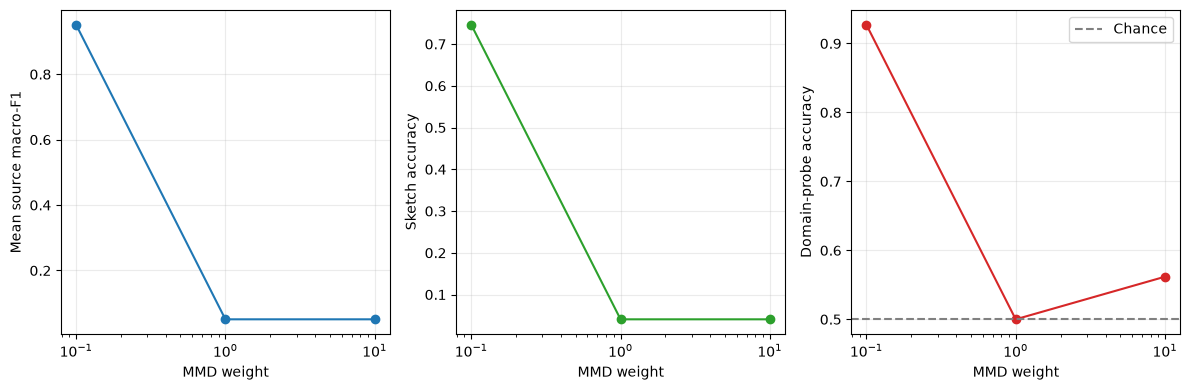

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True)
axes[0].plot(controlled_study["lambda_mmd"], controlled_study["mean_source_f1"], marker="o")
axes[0].set_ylabel("Mean source macro-F1")
axes[1].plot(controlled_study["lambda_mmd"], controlled_study["target_acc"], marker="o",
             color="tab:green")
axes[1].set_ylabel("Sketch accuracy")
axes[2].plot(controlled_study["lambda_mmd"], controlled_study["domain_separability"],
             marker="o", color="tab:red")
axes[2].axhline(0.5, linestyle="--", color="gray", label="Chance")
axes[2].set_ylabel("Domain-probe accuracy")
axes[2].legend()
for axis in axes:
    axis.set_xscale("log")
    axis.set_xlabel("MMD weight")
    axis.grid(alpha=0.25)
emit_figure(
    fig,
    "Controlled DAN study across MMD alignment weights",
    RESULTS_DIR / "controlled_study.png",
)


## 8. Artifact summary

This final cell verifies the required small artifacts. Checkpoints and feature caches are also present locally but ignored by Git. Target metrics in both CSVs are descriptive final analyses only and were never inputs to checkpoint or hyperparameter selection.


In [16]:
required_artifacts = [
    SPLIT_PATH,
    CHECKPOINT_DIR / f"source_only_seed{SEED}.pt",
    CHECKPOINT_DIR / f"source_only_seed{SEED}.json",
    RESULTS_DIR / "main_comparison_table.csv",
    RESULTS_DIR / "per_class_target_accuracy.csv",
    RESULTS_DIR / "controlled_study_results.csv",
    RESULTS_DIR / "controlled_study.png",
    RESULTS_DIR / "pacs_samples.png",
]
missing = [str(path) for path in required_artifacts if not path.exists()]
if missing:
    raise RuntimeError("Missing required artifacts: " + ", ".join(missing))

print("Required artifacts created:")
for path in required_artifacts:
    print(" -", path.relative_to(TASK_DIR))
print("Training curves:", sorted(p.name for p in CURVE_DIR.glob("*.png")))
print("Confusion matrices:", sorted(p.name for p in CONFUSION_DIR.glob("*.png")))
print("Cached diagnostic features:", sorted(p.name for p in CACHE_DIR.glob("*.npz")))


Required artifacts created:
 - results/pacs_splits_seed6304.json
 - results/checkpoints/source_only_seed6304.pt
 - results/checkpoints/source_only_seed6304.json
 - results/main_comparison_table.csv
 - results/per_class_target_accuracy.csv
 - results/controlled_study_results.csv
 - results/controlled_study.png
 - results/pacs_samples.png
Training curves: ['cdan.png', 'dan.png', 'dan_lambda_0p1.png', 'dan_lambda_10.png', 'dann.png', 'source_only.png']
Confusion matrices: ['cdan.png', 'dan.png', 'dann.png', 'source_only.png']
Cached diagnostic features: ['cdan_6755527f17e6_probe_features.npz', 'dan_60e7e2e4ee6f_probe_features.npz', 'dan_7b4b853c36bf_probe_features.npz', 'dan_lambda_0p1_9ada8c932077_probe_features.npz', 'dan_lambda_10_d2a097bf4660_probe_features.npz', 'dan_lambda_1_60e7e2e4ee6f_probe_features.npz', 'dann_53607d7415ec_probe_features.npz', 'dann_9a8fd73295bc_probe_features.npz', 'source_only_a72a81dd25b4_probe_features.npz', 'source_only_faa089501d1f_probe_features.npz']
